In [1]:
import json
from typing import Sequence

import agama
import gc_utils
import h5py
import halo_analysis as halo
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import utilities as ut

In [2]:
sim = "m12i"
sim_dir = "/Users/z5114326/Documents/simulations/"
# sim_dir = "/Volumes/Expansion/simulations/"

sim_code_file = sim_dir + "simulation_codes.json"
with open(sim_code_file, "r") as file:
    sim_codes = json.load(file)

pub_data = sim_dir + "snapshot_times_public.txt"
pub_snaps = pd.read_table(pub_data, comment="#", header=None, sep=r"\s+")
pub_snaps.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]

In [5]:
snap_min = 142
snap_max = 300
group_id = 0
snap_lst = pub_snaps[(snap_min <= pub_snaps["index"]) & (pub_snaps["index"] <= snap_max)]["index"].values

sim_lst = ["m12b", "m12c", "m12f", "m12i", "m12m"]
sim_dict = {sim: {} for sim in sim_lst}

it_id = "it099"

for sim in sim_lst:
    proc_file = sim_dir + sim + "/" + sim + "_processed.hdf5"
    proc_data = h5py.File(proc_file, "r")  # open processed data file

    snp_dat_600 = proc_data[it_id]["snapshots"]["snap600"]
    snp_dat_600_msk = snp_dat_600["group_id"][()] == group_id
    gcid_surv_lst = snp_dat_600["gc_id"][snp_dat_600_msk]

    rel_tid_lst = []
    std_tid_lst = []
    for gcid in gcid_surv_lst:
        tid = []
        for snap in snap_lst:
            snap_id = gc_utils.snapshot_name(snap)
            snp_dat = proc_data[it_id]["snapshots"][snap_id]
            snp_msk = np.isin(snp_dat["gc_id"][()], gcid)

            if np.sum(snp_msk) == 0:
                continue

            tidem = snp_dat["tideig_1"][snp_msk] - snp_dat["tideig_3"][snp_msk]
            tid.append(tidem)

        if len(tid) == 0:
            continue

        # rel_tid = (np.max(tid) - np.min(tid)) / np.mean(tid)
        rel_tid = np.mean(tid)

        rel_tid_lst.append(rel_tid)
        std_tid_lst.append(np.std(tid))

    # sim_dict[sim] = rel_tid_lst
    sim_dict[sim] = rel_tid_lst

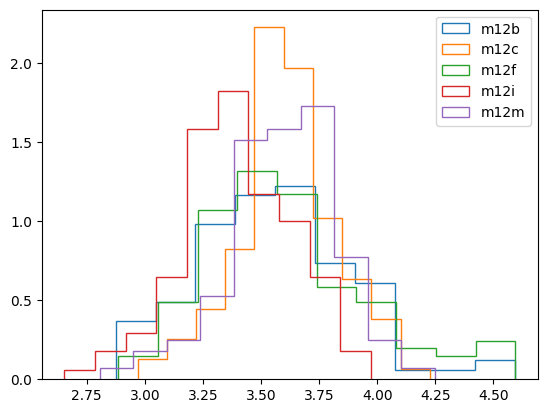

In [6]:
# bins = np.arange(0, 10.5, 0.5)
for sim in sim_lst:
    plt.hist(np.log10(sim_dict[sim]), density=True, histtype="step", label=sim)
plt.legend()

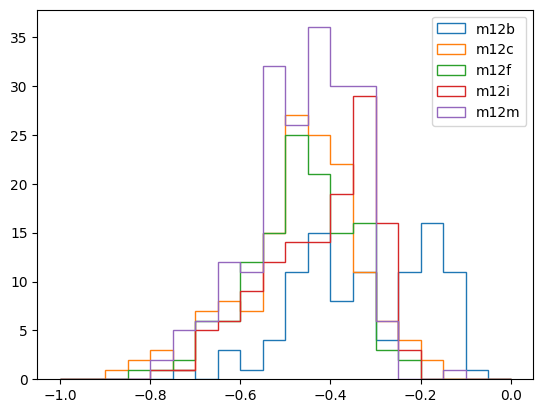

In [7]:
sim_dict = {sim: {} for sim in sim_lst}
for sim in sim_lst:
    proc_file = sim_dir + sim + "/" + sim + "_processed.hdf5"
    proc_data = h5py.File(proc_file, "r")  # open processed data file

    snp_dat_600 = proc_data[it_id]["snapshots"]["snap600"]
    snp_dat_600_msk = snp_dat_600["group_id"][()] == group_id
    gcid_surv_lst = snp_dat_600["gc_id"][snp_dat_600_msk]

    sim_dict[sim] = snp_dat_600["et_norm"][snp_dat_600_msk]

bins = np.arange(-1, 0.05, 0.05)
for sim in sim_lst:
    plt.hist(sim_dict[sim], density=False, histtype="step", label=sim, bins=bins)
plt.legend()

In [9]:
snap_min = 142
snap_max = 486
group_id = 0
snap_lst = pub_snaps[(snap_min <= pub_snaps["index"]) & (pub_snaps["index"] <= snap_max)]["index"].values

sim_lst = ["m12b", "m12c", "m12f", "m12i", "m12m"]
sim_dict = {sim: {} for sim in sim_lst}

it_id = "it099"

for sim in sim_lst:
    proc_file = sim_dir + sim + "/" + sim + "_processed.hdf5"
    proc_data = h5py.File(proc_file, "r")  # open processed data file

    snp_dat_600 = proc_data[it_id]["snapshots"]["snap600"]
    snp_dat_600_msk = snp_dat_600["group_id"][()] == group_id
    gcid_surv_lst = snp_dat_600["gc_id"][snp_dat_600_msk]

    rad_lst = []
    for gcid in gcid_surv_lst:
        tid = []
        for snap in snap_lst:
            snap_id = gc_utils.snapshot_name(snap)
            snp_dat = proc_data[it_id]["snapshots"][snap_id]
            snp_msk = np.isin(snp_dat["gc_id"][()], gcid)

            if np.sum(snp_msk) == 0:
                continue

            tidem = (snp_dat["r_apo"][snp_msk] + snp_dat["r_per"][snp_msk]) / 2
            tid.append(tidem)

        if len(tid) == 0:
            continue

In [12]:
sim_lst = ["m12b", "m12c", "m12f", "m12i", "m12m"]
sim_dict = {sim: {"age": {}, "rad": {}} for sim in sim_lst}

it_id = "it099"

for sim in sim_lst:
    proc_file = sim_dir + sim + "/" + sim + "_processed.hdf5"
    proc_data = h5py.File(proc_file, "r")  # open processed data file

    snp_dat_600 = proc_data[it_id]["snapshots"]["snap600"]
    snp_dat_600_msk = snp_dat_600["group_id"][()] == group_id
    gcid_surv_lst = snp_dat_600["gc_id"][snp_dat_600_msk]
    rad = (snp_dat_600["r_apo"][snp_dat_600_msk] + snp_dat_600["r_per"][snp_dat_600_msk]) / 2

    src_dat = proc_data[it_id]["source"]
    src_msk = np.isin(src_dat["gc_id"][()], gcid_surv_lst)
    age_lst = src_dat["form_time"][src_msk]

    sim_dict[sim]["age"] = age_lst
    sim_dict[sim]["rad"] = rad


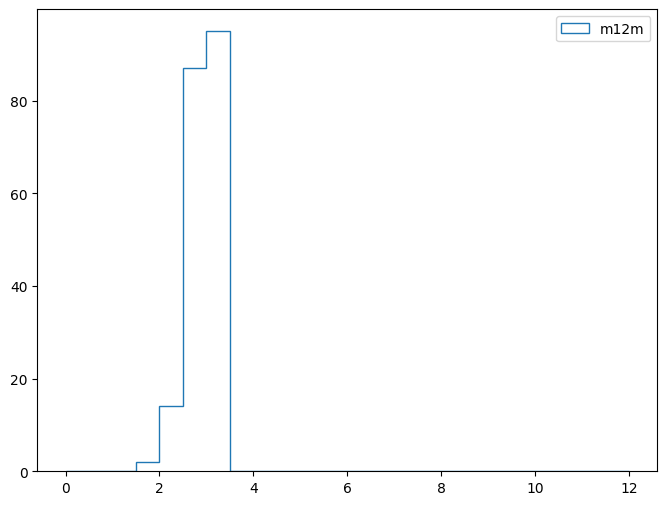

In [13]:
plt.figure(figsize=(8, 6))
bins = np.arange(0, 12.5, 0.5)
for sim in sim_lst:
    if sim != "m12m":
        continue
    plt.hist(sim_dict[sim]["age"], bins=bins, label=sim, alpha=1, density=False, histtype="step")
plt.legend()

In [14]:
for sim in sim_lst:
    print(np.sum(np.array(sim_dict[sim]["age"]) < 8))

96
125
130
163
198


In [15]:
sim_lst = ["m12b", "m12c", "m12f", "m12i", "m12m"]
sim_dict = {sim: [] for sim in sim_lst}

it_id = "it099"

for sim in sim_lst:
    proc_file = sim_dir + sim + "/" + sim + "_processed.hdf5"
    proc_data = h5py.File(proc_file, "r")  # open processed data file

    snp_dat_600 = proc_data[it_id]["snapshots"]["snap600"]
    snp_dat_600_msk = snp_dat_600["group_id"][()] == group_id
    gcid_surv_lst = snp_dat_600["gc_id"][snp_dat_600_msk]

    for snap_id in proc_data[it_id]["snapshots"].keys():
        snap = int(snap_id[4:])
        if snap < 102:
            continue
        snp_dat = proc_data[it_id]["snapshots"][snap_id]
        sim_dict[sim].append((snp_dat["et"][()] / snp_dat["et_norm"][()])[0])

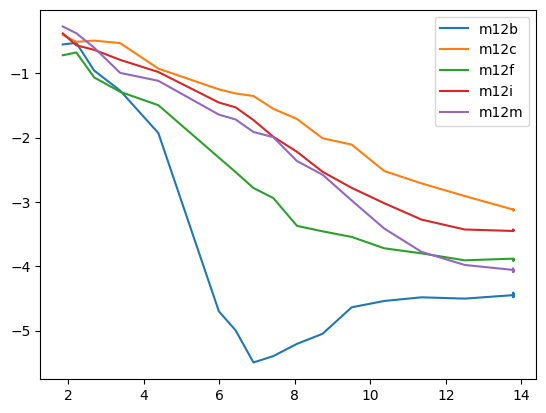

In [17]:
time_lst = pub_snaps[(102 <= pub_snaps["index"])]["time_Gyr"].values
for sim in sim_lst:
    val = -np.array(sim_dict[sim]) * 1e-5
    plt.plot(time_lst, val, label=sim)
plt.legend()

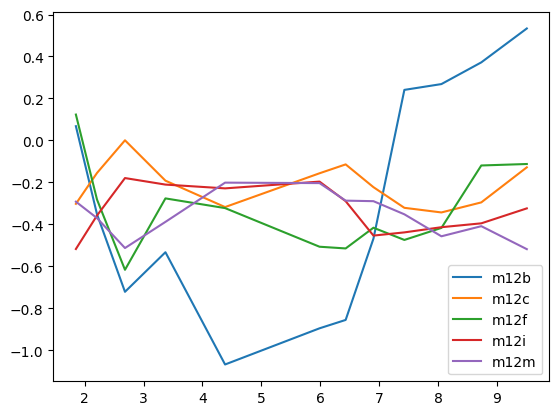

In [18]:
i = 12
time_lst = pub_snaps[(102 <= pub_snaps["index"])]["time_Gyr"].values
for sim in sim_lst:
    val = -np.array(sim_dict[sim][0:i]) * 1e-5
    grad = np.gradient(val[0:i], time_lst[0:i])
    plt.plot(time_lst[0:i], grad, label=sim)
plt.legend()

In [19]:
sim_lst = ["m12b", "m12c", "m12f", "m12i", "m12m"]
sim_dict = {sim: {} for sim in sim_lst}

for sim in sim_lst:
    proc_file = sim_dir + sim + "/" + sim + "_processed.hdf5"
    proc_data = h5py.File(proc_file, "r")  # open processed data file

    for it_id in proc_data.keys():
        sim_dict[sim][it_id] = []
        for snap_id in proc_data[it_id]["snapshots"].keys():
            snap = int(snap_id[4:])
            if snap < 102:
                continue
            snp_dat = proc_data[it_id]["snapshots"][snap_id]
            sur_msk = snp_dat["survive_flag"][()] == 1
            grp_msk = snp_dat["group_id"][()] == 0
            msk = sur_msk & grp_msk

            val = (snp_dat["r_apo"][msk] + snp_dat["r_per"][msk]) / 2

            sim_dict[sim][it_id].append(np.median(val))

/Users/z5114326/Documents/GitHub/gc_statistics/.venv/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/z5114326/Documents/GitHub/gc_statistics/.venv/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [20]:
rad_dict = {sim: 0 for sim in sim_lst}

for sim in sim_lst:
    hld_lst = []
    for it_id in sim_dict[sim].keys():
        hld_lst.append(sim_dict[sim][it_id])
    rad_dict[sim] = np.nanmean(hld_lst, axis=0)

6.903767256

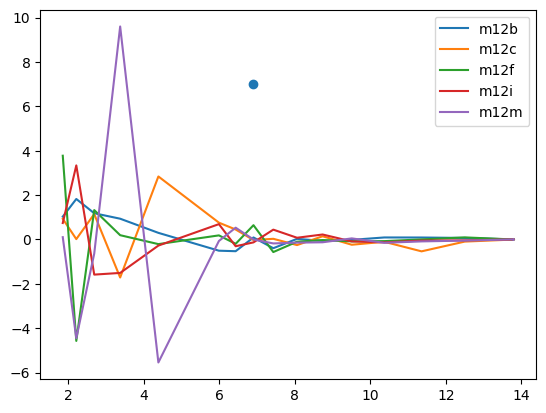

In [21]:
time_lst = pub_snaps[pub_snaps["index"] >= 102]["time_Gyr"].values

for sim in sim_lst:
    plt.plot(time_lst[:-1], np.diff(rad_dict[sim]), label=sim)
plt.legend()

i = 7
plt.scatter(time_lst[i], 7)
time_lst[i]

In [22]:
snap_min = 102
snap_max = 600
group_id = 0
snap_lst = pub_snaps[(snap_min <= pub_snaps["index"]) & (pub_snaps["index"] <= snap_max)]["index"].values

sim_lst = ["m12b", "m12c", "m12f", "m12i", "m12m"]
sim_dict = {sim: {} for sim in sim_lst}

for sim in sim_lst:
    proc_file = sim_dir + sim + "/" + sim + "_processed.hdf5"
    proc_data = h5py.File(proc_file, "r")  # open processed data file

    for it_id in proc_data.keys():
        sim_dict[sim][it_id] = {}
        snp_dat_600 = proc_data[it_id]["snapshots"]["snap600"]
        snp_dat_600_msk = snp_dat_600["group_id"][()] == group_id
        gcid_surv_lst = snp_dat_600["gc_id"][snp_dat_600_msk]

        rad_lst = []
        for gcid in gcid_surv_lst:
            rad_gcid = []
            for snap in snap_lst:
                if snap < 102:
                    continue
                snap_id = gc_utils.snapshot_name(snap)
                snp_dat = proc_data[it_id]["snapshots"][snap_id]
                snp_msk = np.isin(snp_dat["gc_id"][()], gcid)

                if np.sum(snp_msk) == 0:
                    rad_gcid.append(np.nan)
                    continue

                rad = (snp_dat["r_apo"][snp_msk][0] - snp_dat["r_per"][snp_msk][0]) / 2
                rad_gcid.append(rad)

            if len(rad_gcid) == 0:
                continue

            rad_dif = np.diff(rad_gcid)
            rad_lst.append(rad_dif)

        sim_dict[sim][it_id] = np.nanmean(rad_lst, axis=0)

/var/folders/nb/byfjq48d6jz8b3g74s3zr7rh0000gp/T/ipykernel_30931/3388387385.py:42: RuntimeWarning: Mean of empty slice
  sim_dict[sim][it_id] = np.nanmean(rad_lst, axis=0)


In [23]:
rad_dict = {sim: 0 for sim in sim_lst}

for sim in sim_lst:
    hld_lst = []
    for it_id in sim_dict[sim].keys():
        hld_lst.append(sim_dict[sim][it_id])
    rad_dict[sim] = np.nanmean(hld_lst, axis=0)

4.384677047

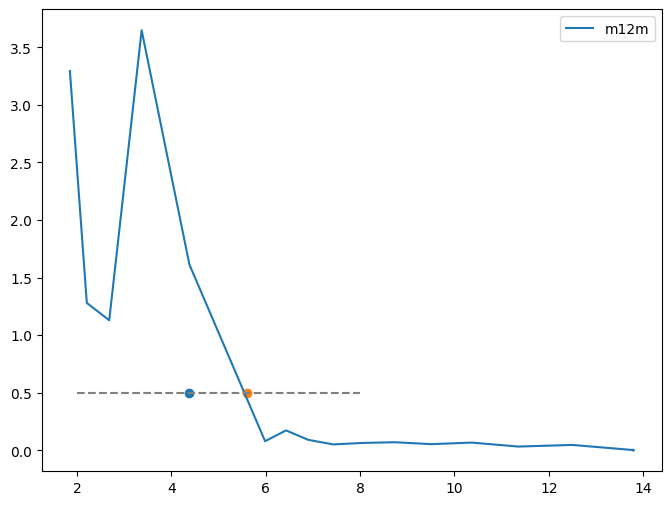

In [37]:
time_lst = pub_snaps[(snap_min <= pub_snaps["index"]) & (pub_snaps["index"] < snap_max)]["time_Gyr"].values

plt.figure(figsize=(8, 6))
for sim in sim_lst:
    if sim != "m12m":
        continue
    plt.plot(time_lst, np.abs(rad_dict[sim]), label=sim)
plt.legend()

plt.plot([2, 8], [0.5, 0.5], ls="--", c="grey")

i = 4
plt.scatter(time_lst[i], 0.5)
plt.scatter(5.6, 0.5)
time_lst[i]